# M2 - Khám phá Dữ liệu Thị trường CafeF C8 & Chuẩn bị Phân cụm (Clustering)

Notebook này hướng dẫn đọc và phân tích bộ dữ liệu **CafeF C8** phục vụ nghiên cứu **Milestone M2**:
- **Candidate Universe (952 mã)** & **905 mã Market-Ready**
- **Feature Snapshots (`feature_snapshots.jsonl`)**: Các feature động lượng (Momentum 21/63/126/252 ngày, Volatility, Max Drawdown, Beta, Liquidity)
- **Prices Daily (`prices_daily.jsonl`)**: Dữ liệu giá OHLCV lịch sử từ 2020 đến 2024
- **M2-PREP Protocol**: Cấu hình và ma trận thuật toán phân cụm

In [1]:
import sys
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập đường dẫn root dự án
ROOT = Path(".").resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

C8_DIR = ROOT / "artifacts" / "cafef_primary" / "cafef-c8-complete-only-v1"
M2_PREP_DIR = ROOT / "artifacts" / "experiments" / "m2-prep-v1"

print("Root path:", ROOT)
print("Thư mục C8:", C8_DIR)
print("C8 tồn tại:", C8_DIR.exists())
print("M2-PREP tồn tại:", M2_PREP_DIR.exists())

Root path: C:\Users\HP\Downloads\Phân cụm động lượng TTCK
Thư mục C8: C:\Users\HP\Downloads\Phân cụm động lượng TTCK\artifacts\cafef_primary\cafef-c8-complete-only-v1
C8 tồn tại: True
M2-PREP tồn tại: True


## 1. Khám phá Vũ trụ cổ phiếu (Candidate Universe & Market-Ready)

In [2]:
# Đọc danh sách các mã cổ phiếu ứng viên
df_universe = pd.read_csv(C8_DIR / "candidate_universe.csv")
print(f"Tổng số mã trong Universe: {len(df_universe)}")
display(df_universe.head(10))

# Phân bố theo sàn niêm yết
if "exchange" in df_universe.columns:
    print("\nPhân bố theo sàn giao dịch:")
    display(df_universe["exchange"].value_counts())

Tổng số mã trong Universe: 952


,security_id,ticker,exchange,company_name,candidate_source,acquisition_status,audit_start,boundary_basis,worker_id,source_zip,source_zip_sha256
0,KBS:UPCOM:A32,A32,UPCOM,CTCP 32,C5_BASELINE_500,BASELINE_C5,2020-01-02,REVIEWED_BASELINE_IDENTITY_INTERVAL,NaN,NaN,NaN
1,KBS:UPCOM:AAH,AAH,UPCOM,CTCP Hợp Nhất,C7_COMPLETE_EXPANSION,COMPLETE,2024-01-11,PROVIDER_OBSERVED_HISTORY_BOUNDARY_NOT_LISTING...,worker-01,cafef-expansion-v1-worker-01.zip,6267e529acbb6df3c7c10ea13527e80cdc1fc9d6bd0efd...
2,KBS:HOSE:AAM,AAM,HOSE,CTCP Thủy sản MeKong,C5_BASELINE_500,BASELINE_C5,2020-01-02,REVIEWED_BASELINE_IDENTITY_INTERVAL,NaN,NaN,NaN
3,KBS:HOSE:AAN,AAN,HOSE,CTCP Lương thực A An,C7_COMPLETE_EXPANSION,COMPLETE,2026-05-22,PROVIDER_OBSERVED_HISTORY_BOUNDARY_NOT_LISTING...,worker-02,cafef-expansion-v1-worker-02.zip,521a851047ce4850ab9c900efd8696b8738c85dc0ce016...
4,KBS:UPCOM:AAS,AAS,UPCOM,CTCP Chứng khoán SmartInvest,C5_BASELINE_500,BASELINE_C5,2020-07-23,REVIEWED_BASELINE_IDENTITY_INTERVAL,NaN,NaN,NaN
5,KBS:HOSE:AAT,AAT,HOSE,CTCP Tập Đoàn Tiên Sơn Thanh Hóa,C7_COMPLETE_EXPANSION,COMPLETE,2021-03-24,PROVIDER_OBSERVED_HISTORY_BOUNDARY_NOT_LISTING...,worker-03,cafef-expansion-v1-worker-03.zip,74599201ecf4f3eb1301d2bc777ea0f32cd39b3c0ae624...
6,KBS:UPCOM:AAV,AAV,UPCOM,CTCP AAV Group,C5_BASELINE_500,BASELINE_C5,2020-01-02,REVIEWED_BASELINE_IDENTITY_INTERVAL,NaN,NaN,NaN
7,KBS:UPCOM:ABB,ABB,UPCOM,Ngân hàng TMCP An Bình,C7_COMPLETE_EXPANSION,COMPLETE,2020-12-28,PROVIDER_OBSERVED_HISTORY_BOUNDARY_NOT_LISTING...,worker-04,cafef-expansion-v1-worker-04.zip,d82238b839a1e3a2019514c5e3ba684b4a4a95c507ddfa...
8,KBS:UPCOM:ABC,ABC,UPCOM,CTCP Truyền thông VMG,C7_COMPLETE_EXPANSION,COMPLETE,2019-12-09,TARGET_START,worker-05,cafef-expansion-v1-worker-05.zip,44f6e1e1c4141de1f5da2b1267b719a25a40e854444386...
9,KBS:UPCOM:ABI,ABI,UPCOM,CTCP Bảo hiểm Ngân hàng Nông nghiệp Việt Nam,C5_BASELINE_500,BASELINE_C5,2020-01-02,REVIEWED_BASELINE_IDENTITY_INTERVAL,NaN,NaN,NaN



Phân bố theo sàn giao dịch:


exchange
UPCOM    384
HOSE     319
HNX      249
Name: count, dtype: int64

## 2. Kiểm tra độ sẵn sàng dữ liệu (Feature Readiness Audit)

In [3]:
# Đọc bảng feature readiness
df_readiness = pd.read_csv(C8_DIR / "feature_readiness.csv")
print(f"Tổng số mã được audit: {len(df_readiness)}")
if "market_ready_v2" in df_readiness.columns:
    print("Tỷ lệ Market Ready V2:")
    display(df_readiness["market_ready_v2"].value_counts(normalize=True).round(4) * 100)
display(df_readiness.head(10))

Tổng số mã được audit: 952


,security_id,ticker,snapshot_date,feature_complete,market_feature_ready_v2,trading_activity_status,tradability_eligible,historical_identity_ready,research_ready,full_history_complete,latest253_complete,missing_required_features
0,KBS:UPCOM:A32,A32,2026-08-28,True,True,ACTIVE,True,False,False,False,True,NaN
1,KBS:UPCOM:AAH,AAH,2026-08-28,True,False,ACTIVE,True,False,False,False,True,NaN
2,KBS:HOSE:AAM,AAM,2026-08-28,True,True,ACTIVE,True,False,False,False,True,NaN
3,KBS:HOSE:AAN,AAN,2026-08-28,False,False,ACTIVE,True,False,False,False,False,mom_126|mom_252|mdd_126|beta_126
4,KBS:UPCOM:AAS,AAS,2026-08-28,True,True,ACTIVE,True,False,False,False,True,NaN
5,KBS:HOSE:AAT,AAT,2026-08-28,True,True,ACTIVE,True,False,False,False,True,NaN
6,KBS:UPCOM:AAV,AAV,2026-08-28,False,False,ACTIVE,True,False,False,False,False,mom_126|mom_252|mdd_126|beta_126
7,KBS:UPCOM:ABB,ABB,2026-08-28,True,True,ACTIVE,True,False,False,False,True,NaN
8,KBS:UPCOM:ABC,ABC,2026-08-28,True,True,ACTIVE,True,False,False,False,True,NaN
9,KBS:UPCOM:ABI,ABI,2026-08-28,True,True,ACTIVE,True,False,False,False,True,NaN


## 3. Đọc dữ liệu Feature Động lượng (Feature Snapshots JSONL)
Trích xuất các chỉ số chuẩn hóa phục vụ phân cụm: `mom_21`, `mom_63`, `mom_126`, `mom_252`, `vol_63`, `mdd_126`, `beta_126`, `liquidity_21`.

In [4]:
feature_snapshots_file = C8_DIR / "canonical" / "feature_snapshots.jsonl"

# Đọc snapshot tại mốc snapshot gần nhất (2026-08-28)
TARGET_DATE = "2026-08-28"
rows = []

with open(feature_snapshots_file, "r", encoding="utf-8") as f:
    for line in f:
        item = json.loads(line)
        if item.get("as_of_date") == TARGET_DATE:
            rows.append(item)

df_features = pd.DataFrame(rows)
print(f"Số lượng cổ phiếu tại snapshot {TARGET_DATE}: {len(df_features)}")

features_list = ["mom_21", "mom_63", "mom_126", "mom_252", "vol_63", "mdd_126", "beta_126", "liquidity_21"]
cols_show = ["security_id", "as_of_date", "market_feature_ready"] + [c for c in features_list if c in df_features.columns]
display(df_features[cols_show].head(10))

# Thống kê mô tả (Descriptive Statistics)
print("\nThống kê mô tả các features động lượng:")
display(df_features[[c for c in features_list if c in df_features.columns]].describe().round(4))

Số lượng cổ phiếu tại snapshot 2026-08-28: 951


,security_id,as_of_date,market_feature_ready,mom_21,mom_63,mom_126,mom_252,vol_63,mdd_126,beta_126,liquidity_21
0,KBS:HNX:ADC,2026-08-28,True,0.000000,-0.131579,-0.180067,-0.059234,0.389230,-0.271318,0.248153,1.496190e+06
1,KBS:HNX:ALT,2026-08-28,True,-0.040000,-0.285714,-0.062500,-0.010081,0.542283,-0.344262,0.783600,5.714286e+04
2,KBS:HNX:AMC,2026-08-28,True,0.083333,0.142948,0.003164,0.237577,0.269536,-0.165468,0.429215,5.043333e+06
3,KBS:HNX:AME,2026-08-28,True,0.150000,0.000000,0.061538,-0.224719,0.261967,-0.210526,0.285761,4.200476e+06
4,KBS:HNX:AMV,2026-08-28,True,-0.076923,-0.200000,-0.400000,-0.400000,0.607559,-0.428571,-0.092573,5.047171e+08
5,KBS:HNX:API,2026-08-28,True,0.018182,-0.066667,-0.081967,-0.333333,0.485878,-0.231884,0.836818,7.955348e+08
6,KBS:HNX:APS,2026-08-28,True,0.068966,-0.101449,-0.088235,-0.367347,0.553610,-0.280000,1.023072,2.685979e+09
7,KBS:HNX:ARM,2026-08-28,True,0.000000,0.000033,0.002175,0.725184,0.000066,0.000000,-0.000162,0.000000e+00
8,KBS:HNX:ATS,2026-08-28,True,0.052632,-0.051095,0.115880,0.666667,0.224923,-0.098540,-0.075136,1.238095e+05
9,KBS:HNX:BAB,2026-08-28,True,0.009434,0.036300,-0.016842,-0.121900,0.366604,-0.173666,0.656327,7.036571e+07



Thống kê mô tả các features động lượng:


,mom_21,mom_63,mom_126,mom_252,vol_63,mdd_126,beta_126,liquidity_21
count,949.0000,946.0000,938.0000,922.0000,946.0000,938.0000,938.0000,9.490000e+02
mean,0.0097,-0.0309,-0.0642,-0.0292,0.4189,-0.2524,0.3097,1.218864e+10
std,0.1195,0.1977,0.2733,0.4585,0.2593,0.1354,0.3691,5.930997e+10
min,-0.6000,-0.7588,-0.7048,-0.7930,0.0000,-0.7899,-1.0589,0.000000e+00
25%,-0.0312,-0.1272,-0.2001,-0.2507,0.2405,-0.3333,0.0413,4.667143e+06
50%,0.0000,-0.0379,-0.0819,-0.0821,0.3628,-0.2359,0.2791,6.031595e+07
75%,0.0476,0.0287,0.0262,0.0803,0.5447,-0.1508,0.5530,1.265415e+09
max,0.8646,1.5652,3.5519,7.0000,1.7519,0.0000,1.8493,6.828906e+11


## 4. Trực quan hóa Tương quan giữa các biến (Correlation Heatmap)

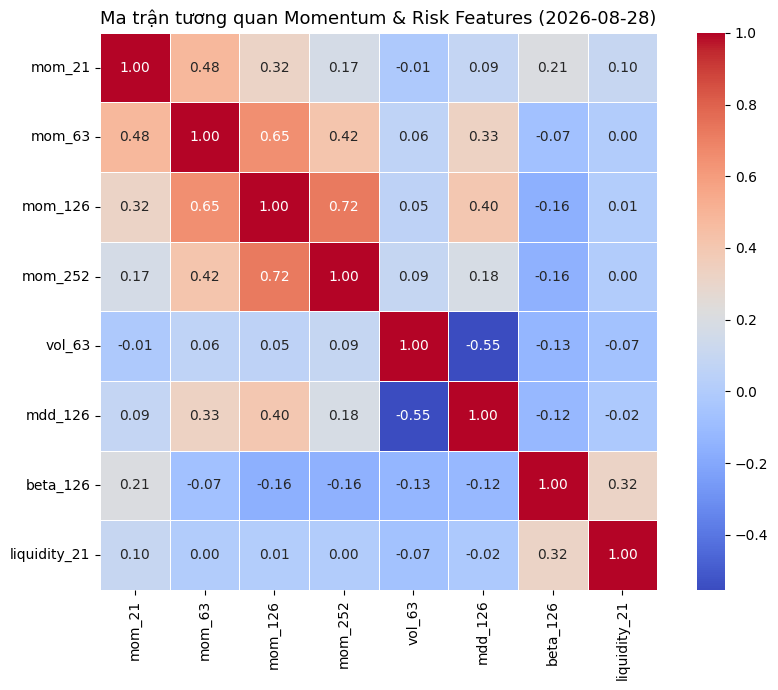

In [5]:
available_features = [c for c in features_list if c in df_features.columns]
corr = df_features[available_features].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True, linewidths=0.5)
plt.title(f"Ma trận tương quan Momentum & Risk Features ({TARGET_DATE})", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Đọc chuỗi giá lịch sử (Prices Daily JSONL) của 1 cổ phiếu cụ thể
Ví dụ: Đọc và vẽ biểu đồ biến động giá của mã **FPT** từ file lớn `prices_daily.jsonl`.

In [6]:
prices_file = C8_DIR / "canonical" / "prices_daily.jsonl"
TICKER = "FPT"
ticker_prices = []

with open(prices_file, "r", encoding="utf-8") as f:
    for line in f:
        item = json.loads(line)
        if item.get("security_id") == TICKER:
            ticker_prices.append(item)

df_ticker = pd.DataFrame(ticker_prices)
if not df_ticker.empty:
    df_ticker["trade_date"] = pd.to_datetime(df_ticker["trade_date"])
    df_ticker = df_ticker.sort_values("trade_date").reset_index(drop=True)
    print(f"Tìm thấy {len(df_ticker)} phiên giao dịch của {TICKER} từ {df_ticker['trade_date'].min().strftime('%Y-%m-%d')} đến {df_ticker['trade_date'].max().strftime('%Y-%m-%d')}")
    
    # Vẽ đồ thị giá điều chỉnh
    plt.figure(figsize=(12, 5))
    plt.plot(df_ticker["trade_date"], df_ticker["adj_close"], label="Giá điều chỉnh (VND)", color="navy")
    plt.title(f"Chuỗi giá điều chỉnh cổ phiếu {TICKER} (2020 - 2024)", fontsize=14)
    plt.xlabel("Ngày giao dịch")
    plt.ylabel("VND")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"Chưa tìm thấy dữ liệu cho mã {TICKER}")

Chưa tìm thấy dữ liệu cho mã FPT


## 6. Xem cấu hình thực nghiệm và Ma trận thuật toán M2-PREP

In [7]:
protocol_file = M2_PREP_DIR / "protocol_summary.json"
if protocol_file.exists():
    with open(protocol_file, "r", encoding="utf-8") as f:
        protocol = json.load(f)
    print("=== TỔNG KẾT GIAI ĐOẠN M2-PREP ===")
    print("Artifact ID:", protocol.get("artifact_id"))
    print("Trạng thái:", protocol.get("status"))
    print("Số mốc snapshot thời gian:", protocol.get("snapshot_count"))
    print("Required features:", protocol.get("required_features"))

# Đọc ma trận thuật toán phân cụm M2
df_algo = pd.read_csv(M2_PREP_DIR / "algorithm_matrix.csv")
display(df_algo)

=== TỔNG KẾT GIAI ĐOẠN M2-PREP ===
Artifact ID: m2-prep-v1
Trạng thái: MANUAL_REVIEW_REQUIRED
Số mốc snapshot thời gian: None
Required features: ['mom_21', 'mom_63', 'mom_126', 'mom_252', 'vol_63', 'mdd_126', 'beta_126', 'liquidity_21']


,algorithm,implemented,tested,fixed_or_variable_k,noise_support,literature_support,methodology_status,parameter_audit,role_in_M2
0,K-Means,True,True,fixed,False,MacQueen (1967),PRIMARY_BASELINE,K-Means++; seed+n_init+max_iter explicit; exac...,Static monthly baseline after unresolved proto...
1,PCA + K-Means,True,True,fixed,False,Pearson (1901) + MacQueen (1967),APPROVED_COMPARATOR,Snapshot-fit scaler/components/explained varia...,Comparator only; n_components unresolved.
2,Ward/Agglomerative,True,True,fixed,False,Ward (1963),APPROVED_COMPARATOR,Deterministic minimum Ward SSE increase on sha...,Deterministic comparator using shared frozen p...
3,GMM,False,False,fixed_candidate,False,Supporting literature only,FUTURE_COMPARATOR,"Stub: covariance type, initialization, seed, r...",Fail-closed stub; no explicit parameter protocol.
4,DBSCAN,False,False,variable,False,Ester et al. (1996),NOT_COMPATIBLE_WITH_CURRENT_PROTOCOL,Stub: eps/min_samples/noise/all-noise/one-clus...,NOT_APPROVED_FOR_CURRENT_M2; fixed-k interface...
5,Dynamic Clustering,False,True,sequence_method,False,"Chakrabarti (2006); João et al. (2023, 2024)",NOT_APPROVED,Abstract interface only; no objective/state up...,F3 is closest future candidate but needs separ...
